# Movie Rental Data Warehouse

This notebook includes:
- Extracting data
- Creating dimensions
- Creating fact tables

In [1]:
import pandas as pd
import sqlalchemy
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt



In [2]:
from urllib.parse import quote_plus
from sqlalchemy import create_engine

username = "root"
password = quote_plus("db2magdw2026@")

host = "127.0.0.1"
port = 3306

srcDatabase = "test2"
dstDatabase = "movie_rental_dw"

srcConnection_string = f"mysql+pymysql://{username}:{password}@{host}:{port}/{srcDatabase}"

dstConnection_string = f"mysql+pymysql://{username}:{password}@{host}:{port}/{dstDatabase}"

engine1 = create_engine(srcConnection_string)
engine2 = create_engine(dstConnection_string)

## Database Connection and Engine Setup

from urllib.parse import quote_plus

* `quote_plus()` is used to encode special characters in the password.
* Special characters like `@`, `%`, `/`, `:` may cause connection errors.
* It converts them into a safe URL format.

Example:

"pass@123"  →  "pass%40123"


from sqlalchemy import create_engine


* `create_engine()` is used to create a connection between Python and MySQL.
* The engine allows Python to execute SQL queries.
* It is commonly used with pandas and SQLAlchemy.



In [3]:
print("Connection Successful")

Connection Successful


# Loading Source Tables

In this step, the tables are loaded from the original movie rental database to start building the data warehouse.

In [4]:
customer_df = pd.read_sql("SELECT * FROM customer", engine1)

film_df = pd.read_sql("SELECT * FROM film", engine1)

rental_df = pd.read_sql("SELECT * FROM rental", engine1)

payment_df = pd.read_sql("SELECT * FROM payment", engine1)

inventory_df = pd.read_sql("SELECT * FROM inventory", engine1)

store_df = pd.read_sql("SELECT * FROM store", engine1)

staff_df = pd.read_sql("SELECT * FROM staff", engine1)

category_df = pd.read_sql("SELECT * FROM category", engine1)

film_category_df = pd.read_sql("SELECT * FROM film_category", engine1)

language_df = pd.read_sql("SELECT * FROM language", engine1)

address_df = pd.read_sql("SELECT * FROM address", engine1)

city_df = pd.read_sql("SELECT * FROM city", engine1)

country_df = pd.read_sql("SELECT * FROM country", engine1)

print("Data Extracted")

Data Extracted


<!-- **Creating Customer Dimension**

The customer dimension stores descriptive information about customers.

This dimension is used to support customer-related analysis such as:

customer activity
rental behavior
payment analysis
customer distribution by city and country

Customer data is combined with address, city, and country tables to provide complete location details for reporting and analytical purposes. -->

# Dim Date ETL

This ETL process extracts rental dates from the source system, transforms them into date attributes, and loads them into the `dim_date` dimension table.

In [5]:



# 1. Extract

query = """
SELECT DISTINCT rental_date 
FROM rental
WHERE rental_date IS NOT NULL
"""
rental_df = pd.read_sql(query, engine1)


# 2. Transform

rental_df['rental_date'] = pd.to_datetime(rental_df['rental_date'])

dim_date = pd.DataFrame()

dim_date['full_date'] = rental_df['rental_date'].dt.date
dim_date['date_key'] = rental_df['rental_date'].dt.strftime('%Y%m%d').astype(int)
dim_date['day_name'] = rental_df['rental_date'].dt.day_name()
dim_date['month_number'] = rental_df['rental_date'].dt.month
dim_date['month_name'] = rental_df['rental_date'].dt.month_name()
dim_date['year'] = rental_df['rental_date'].dt.year
dim_date['quarter'] = rental_df['rental_date'].dt.quarter

dim_date['day_of_week'] = rental_df['rental_date'].dt.dayofweek + 1 
dim_date['is_weekend'] = dim_date['day_of_week'].isin([6, 7]).astype(int)  


dim_date = dim_date.drop_duplicates(subset=['date_key'])
dim_date = dim_date.sort_values(by='full_date')


# 3. Load


try:
    # Get the existing keys from the database to avoid duplicates.

    existing_keys_query = "SELECT date_key FROM dim_date"
    
    try:
        existing_keys_df = pd.read_sql(existing_keys_query, engine2)
        existing_keys_list = existing_keys_df['date_key'].tolist()
    except:
        #If the table is completely new and has not been created yet, the list will be empty.

        existing_keys_list = []

    #Keep only the new dates that do not already exist.
    new_dim_date = dim_date[~dim_date['date_key'].isin(existing_keys_list)]

    # If there is new data, we add it.
    if not new_dim_date.empty:
        new_dim_date.to_sql(
            "dim_date",
            engine2,
            if_exists="append",  
            index=False,
            dtype={
                'date_key': sqlalchemy.types.Integer(),
                'full_date': sqlalchemy.types.Date(),
                'year': sqlalchemy.types.Integer(),
                'month_number': sqlalchemy.types.Integer(),
                'quarter': sqlalchemy.types.Integer(),
                'is_weekend': sqlalchemy.types.Integer()
            }
        )
        print(f" Successfully added {len(new_dim_date)} new rows to dim_date.")
    else:
        print(" No new dates to add. Data is up to date.")

except Exception as e:
    print(f" Error loading data: {e}")

 No new dates to add. Data is up to date.


# Dim Store ETL

This ETL process extracts store and location information, transforms it into dimensional attributes, and loads it into the `dim_store` table.

In [6]:



# Extract


store_query = """
SELECT
    s.store_id,
    st.first_name AS manager_first_name,
    st.last_name AS manager_last_name,
    c.city,
    co.country
FROM store s
JOIN staff st ON s.manager_staff_id = st.staff_id
JOIN address a ON s.address_id = a.address_id
JOIN city c ON a.city_id = c.city_id
JOIN country co ON c.country_id = co.country_id
"""
store_df = pd.read_sql(store_query, engine1)


# Transform


dim_store = store_df.drop_duplicates(subset=['store_id'])


# Load


try:
    #Get the existing store_id values from the target database.
    existing_ids_query = "SELECT store_id FROM dim_store"
    
    try:
        existing_ids_df = pd.read_sql(existing_ids_query, engine2)
        existing_ids_list = existing_ids_df['store_id'].tolist()
    except:
        #  If the table is new and has not been created yet

        existing_ids_list = []

    # Filter only the new rows that do not already exist
    new_stores = dim_store[~dim_store['store_id'].isin(existing_ids_list)]

    # If there is new data, we add it.
    if not new_stores.empty:
        new_stores.to_sql(
            "dim_store",
            engine2,
            if_exists="append",  # We use append to avoid breaking the Foreign Key
            index=False,
            dtype={
                'store_id': sqlalchemy.types.Integer(),
                'manager_first_name': sqlalchemy.types.String(50),
                'manager_last_name': sqlalchemy.types.String(50),
                'city': sqlalchemy.types.String(50),
                'country': sqlalchemy.types.String(50)
            }
        )
        print(f" Successfully added {len(new_stores)} new rows to dim_store.")
    else:
        print(" No new stores to add. Data is up to date.")

except Exception as e:
    print(f" Error loading data: {e}")

 No new stores to add. Data is up to date.


# Dim Staff ETL

This ETL process extracts staff information and links each staff member to the corresponding store dimension.

In [7]:



# 1. Extract

staff_query = """
SELECT staff_id, first_name, last_name, email, store_id
FROM staff
"""
staff_df = pd.read_sql(staff_query, engine1)





store_dim = pd.read_sql(
    "SELECT store_key, store_id FROM dim_store",
    engine2
)


staff_df = staff_df.merge(store_dim, on='store_id', how='left')


# 3. Transform

dim_staff = staff_df[['staff_id', 'first_name', 'last_name', 'email', 'store_key']].copy()
dim_staff = dim_staff.drop_duplicates(subset=['staff_id'])


# 4. Load 

try:
    
    existing_staff_query = "SELECT staff_id FROM dim_staff"
    try:
        existing_staff_df = pd.read_sql(existing_staff_query, engine2)
        existing_staff_ids = existing_staff_df['staff_id'].tolist()
    except:
        
        existing_staff_ids = []


    new_staff = dim_staff[~dim_staff['staff_id'].isin(existing_staff_ids)]

    if not new_staff.empty:
        new_staff.to_sql(
            "dim_staff",
            engine2,
            if_exists="append",  
            index=False,
            dtype={
                'staff_id': sqlalchemy.types.Integer(),
                'first_name': sqlalchemy.types.String(50),
                'last_name': sqlalchemy.types.String(50),
                'email': sqlalchemy.types.String(100),
                'store_key': sqlalchemy.types.Integer()
            }
        )
        print(f" Successfully added {len(new_staff)} new staff members.")
    else:
        print(" No new staff to add. Data is up to date.")

except Exception as e:
    print(f" Error loading dim_staff: {e}")

 No new staff to add. Data is up to date.


# Dim Customer ETL

This ETL process extracts customer information and transforms customer attributes for analytical purposes.

In [8]:



# 1. Extract

customer_query = """
SELECT customer_id, first_name, last_name, email, active, create_date
FROM customer
"""
customer_df = pd.read_sql(customer_query, engine1)


# 2. Transform

customer_df['full_name'] = customer_df['first_name'] + ' ' + customer_df['last_name']


dim_customer = customer_df[[
    'customer_id', 
    'first_name', 
    'last_name', 
    'full_name', 
    'email', 
    'active', 
    'create_date'
]].copy()

dim_customer = dim_customer.drop_duplicates(subset=['customer_id'])


# 3. Load 

try:
    
    existing_ids_query = "SELECT customer_id FROM dim_customer"
    try:
        existing_ids_df = pd.read_sql(existing_ids_query, engine2)
        existing_ids_list = existing_ids_df['customer_id'].tolist()
    except:
       
        existing_ids_list = []

    
    new_customers = dim_customer[~dim_customer['customer_id'].isin(existing_ids_list)]

    if not new_customers.empty:
        new_customers.to_sql(
            "dim_customer",
            engine2,
            if_exists="append",
            index=False,
            dtype={
                'customer_id': sqlalchemy.types.Integer(),
                'first_name': sqlalchemy.types.String(50),
                'last_name': sqlalchemy.types.String(50),
                'full_name': sqlalchemy.types.String(101),
                'email': sqlalchemy.types.String(100),
                'active': sqlalchemy.types.Integer(),
                'create_date': sqlalchemy.types.DateTime()
            }
        )
        print(f" Successfully added {len(new_customers)} new customers to dim_customer.")
    else:
        print(" No new customers to add. Data is up to date.")

except Exception as e:
    print(f" Error loading dim_customer: {e}")

 No new customers to add. Data is up to date.


# Dim Film ETL

This ETL process extracts film information, category, and language details to build the `dim_film` dimension.

In [9]:



# 1. Extract

film_query = """
SELECT
    f.film_id,
    f.title,
    f.description,
    f.release_year,
    f.rental_duration,
    f.rental_rate,
    f.length AS length_minutes,
    f.replacement_cost,
    f.rating,
    c.name AS category_name,
    l.name AS language_name
FROM film f
JOIN film_category fc ON f.film_id = fc.film_id
JOIN category c ON fc.category_id = c.category_id
JOIN language l ON f.language_id = l.language_id
"""
film_df = pd.read_sql(film_query, engine1)


# 2. Transform


dim_film = film_df.drop_duplicates(subset=['film_id']).copy()


# 3. Load 

try:
    
    existing_ids_query = "SELECT film_id FROM dim_film"
    try:
        existing_ids_df = pd.read_sql(existing_ids_query, engine2)
        existing_ids_list = existing_ids_df['film_id'].tolist()
    except:
        existing_ids_list = []  

    
    new_films = dim_film[~dim_film['film_id'].isin(existing_ids_list)]

    if not new_films.empty:
        new_films.to_sql(
            "dim_film",
            engine2,
            if_exists="append",
            index=False,
            dtype={
                'film_id': sqlalchemy.types.Integer(),
                'title': sqlalchemy.types.String(255),
                'description': sqlalchemy.types.Text(),
                'release_year': sqlalchemy.types.Integer(),
                'rental_duration': sqlalchemy.types.Integer(),
                'rental_rate': sqlalchemy.types.Float(),
                'length_minutes': sqlalchemy.types.Integer(),
                'replacement_cost': sqlalchemy.types.Float(),
                'rating': sqlalchemy.types.String(10),
                'category_name': sqlalchemy.types.String(50),
                'language_name': sqlalchemy.types.String(50)
            }
        )
        print(f" Successfully added {len(new_films)} new films to dim_film.")
    else:
        print(" No new films to add. Data is up to date.")

except Exception as e:
    print(f" Error loading dim_film: {e}")

 No new films to add. Data is up to date.


# Fact Rental ETL

This ETL process extracts rental transactions, transforms business metrics, links dimension surrogate keys, and loads the data into the `fact_rental` table.

In [10]:


# =========================
# 1. Extract
# =========================
rental_query = """
SELECT
    r.rental_id,
    r.rental_date,
    r.return_date,
    r.customer_id,
    i.film_id,
    s.store_id,
    r.staff_id
FROM rental r
JOIN inventory i ON r.inventory_id = i.inventory_id
JOIN staff s ON r.staff_id = s.staff_id
"""
rental_df = pd.read_sql(rental_query, engine1)

# =========================
# 2. Transform
# =========================
rental_df['rental_date'] = pd.to_datetime(rental_df['rental_date'])
rental_df['return_date'] = pd.to_datetime(rental_df['return_date'])

rental_df['date_key'] = rental_df['rental_date'].dt.strftime('%Y%m%d').astype(int)

# 
rental_df['rental_duration_days'] = (rental_df['return_date'] - rental_df['rental_date']).dt.days

## Detecting delays (safely handles missing values and converts the result to 0/1)

rental_df['is_late_return'] = (rental_df['rental_duration_days'].gt(7)).fillna(False).astype(int)


# 3. Get Dimension Keys

# Using `how='left'` ensures that all rental records remain even if there is an issue linking a certain dimension.

rental_df = rental_df.merge(
    pd.read_sql("SELECT customer_key, customer_id FROM dim_customer", engine2),
    on='customer_id', how='left'
)
rental_df = rental_df.merge(
    pd.read_sql("SELECT film_key, film_id FROM dim_film", engine2),
    on='film_id', how='left'
)
rental_df = rental_df.merge(
    pd.read_sql("SELECT store_key, store_id FROM dim_store", engine2),
    on='store_id', how='left'
)
rental_df = rental_df.merge(
    pd.read_sql("SELECT staff_key, staff_id FROM dim_staff", engine2),
    on='staff_id', how='left'
)


# 4. Final Fact Table

fact_rental = rental_df[[
    'rental_id', 'date_key', 'customer_key', 'film_key',
    'store_key', 'staff_key', 'rental_duration_days', 'is_late_return'
]].copy()

fact_rental = fact_rental.drop_duplicates(subset=['rental_id'])


# 5. Load 

try:
    existing_ids_query = "SELECT rental_id FROM fact_rental"
    try:
        existing_ids_df = pd.read_sql(existing_ids_query, engine2)
        existing_ids_list = existing_ids_df['rental_id'].tolist()
    except:
        existing_ids_list = []  

    new_rentals = fact_rental[~fact_rental['rental_id'].isin(existing_ids_list)]

    if not new_rentals.empty:
        new_rentals.to_sql(
            "fact_rental",
            engine2,
            if_exists="append",
            index=False,
            dtype={
                'rental_id': sqlalchemy.types.Integer(),
                'date_key': sqlalchemy.types.Integer(),
                'customer_key': sqlalchemy.types.Integer(),
                'film_key': sqlalchemy.types.Integer(),
                'store_key': sqlalchemy.types.Integer(),
                'staff_key': sqlalchemy.types.Integer(),
                'rental_duration_days': sqlalchemy.types.Integer(),
                'is_late_return': sqlalchemy.types.Integer()
            }
        )
        print(f" Successfully added {len(new_rentals)} new rentals to fact_rental.")
    else:
        print(" No new rentals to add. Data is up to date.")

except Exception as e:
    print(f" Error loading fact_rental: {e}")

 No new rentals to add. Data is up to date.


# Fact Payment ETL

This ETL process extracts payment transactions, links related dimensions and rental facts, and loads the data into the `fact_payment` table.


In [11]:



# 1. Extract

payment_query = """
SELECT payment_id, customer_id, staff_id, rental_id, payment_date, amount
FROM payment
"""
payment_df = pd.read_sql(payment_query, engine1)


# 2. Transform

payment_df['payment_date'] = pd.to_datetime(payment_df['payment_date'])
payment_df['date_key'] = payment_df['payment_date'].dt.strftime('%Y%m%d').astype(int)

# 3. Get Dimension & Fact Keys

customer_dim = pd.read_sql("SELECT customer_key, customer_id FROM dim_customer", engine2)
staff_dim    = pd.read_sql("SELECT staff_key, staff_id FROM dim_staff", engine2)
rental_fact  = pd.read_sql("SELECT rental_key, rental_id FROM fact_rental", engine2)

#Merging data using LEFT JOIN to avoid losing any payment records.

payment_df = payment_df.merge(customer_dim, on='customer_id', how='left')
payment_df = payment_df.merge(staff_dim,    on='staff_id',    how='left')
payment_df = payment_df.merge(rental_fact,  on='rental_id',   how='left')

# 4. Final Fact Table

fact_payment = payment_df[[
    'payment_id', 'date_key', 'customer_key', 'staff_key', 'rental_key', 'amount'
]].copy()

## Preventing Duplication Based on the Primary Key

fact_payment = fact_payment.drop_duplicates(subset=['payment_id'])

# 5. Load 

try:
    existing_ids_query = "SELECT payment_id FROM fact_payment"
    try:
        existing_ids_df = pd.read_sql(existing_ids_query, engine2)
        existing_ids_list = existing_ids_df['payment_id'].tolist()
    except:
        existing_ids_list = [] 

    new_payments = fact_payment[~fact_payment['payment_id'].isin(existing_ids_list)]

    if not new_payments.empty:
        new_payments.to_sql(
            "fact_payment",
            engine2,
            if_exists="append",
            index=False,
            dtype={
                'payment_id': sqlalchemy.types.Integer(),
                'date_key': sqlalchemy.types.Integer(),
                'customer_key': sqlalchemy.types.Integer(),
                'staff_key': sqlalchemy.types.Integer(),
                'rental_key': sqlalchemy.types.Integer(),
                'amount': sqlalchemy.types.Float()
            }
        )
        print(f" Successfully added {len(new_payments)} new payments to fact_payment.")
    else:
        print(" No new payments to add. Data is up to date.")

except Exception as e:
    print(f" Error loading fact_payment: {e}")

 No new payments to add. Data is up to date.


*Revenue by Month*

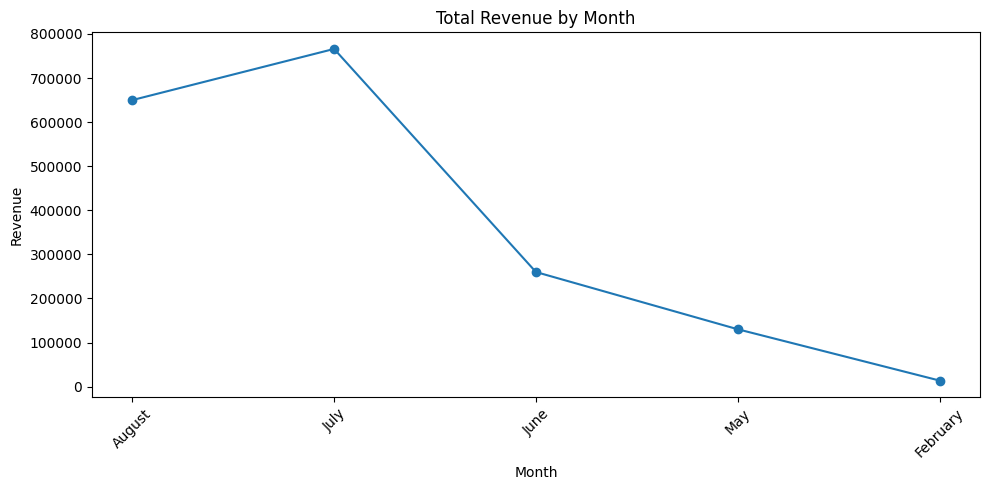

In [12]:
query = """
SELECT 
    d.month_name,
    d.year,
    SUM(fp.amount) AS total_revenue
FROM fact_payment fp
JOIN dim_date d 
    ON fp.date_key = d.date_key
GROUP BY d.year, d.month_name
ORDER BY d.year
"""

revenue_df = pd.read_sql(query, engine2)

plt.figure(figsize=(10,5))
plt.plot(revenue_df['month_name'], revenue_df['total_revenue'], marker='o')

plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Rentals by Film Category

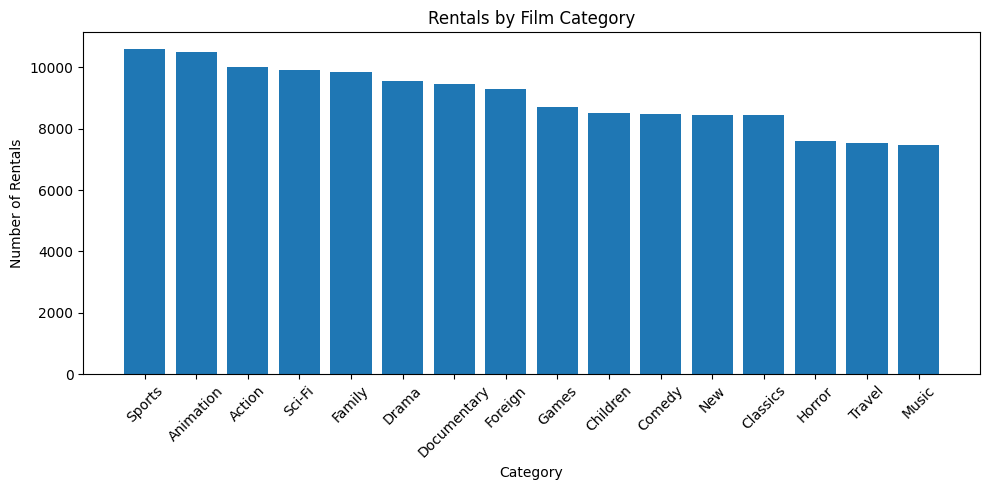

In [13]:
query = """
SELECT 
    df.category_name,
    COUNT(fr.rental_id) AS total_rentals
FROM fact_rental fr
JOIN dim_film df
    ON fr.film_key = df.film_key
GROUP BY df.category_name
ORDER BY total_rentals DESC
"""

category_df = pd.read_sql(query, engine2)

plt.figure(figsize=(10,5))
plt.bar(category_df['category_name'], category_df['total_rentals'])

plt.title("Rentals by Film Category")
plt.xlabel("Category")
plt.ylabel("Number of Rentals")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top Customers by Payments

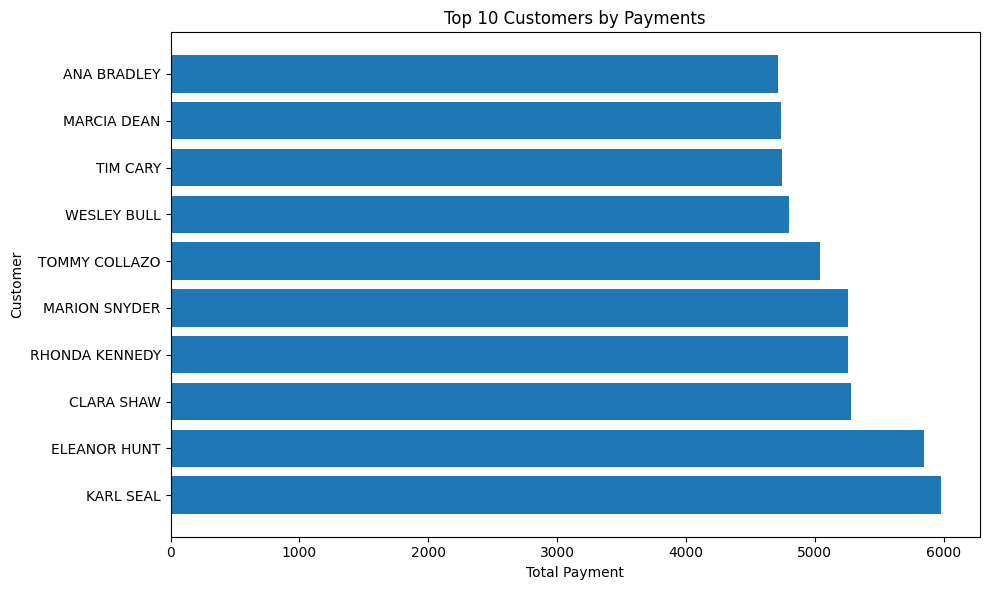

In [14]:
query = """
SELECT 
    dc.full_name,
    SUM(fp.amount) AS total_payment
FROM fact_payment fp
JOIN dim_customer dc
    ON fp.customer_key = dc.customer_key
GROUP BY dc.full_name
ORDER BY total_payment DESC
LIMIT 10
"""

customer_df = pd.read_sql(query, engine2)

plt.figure(figsize=(10,6))
plt.barh(customer_df['full_name'], customer_df['total_payment'])

plt.title("Top 10 Customers by Payments")
plt.xlabel("Total Payment")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

Late Return Analysis (Pie Chart)

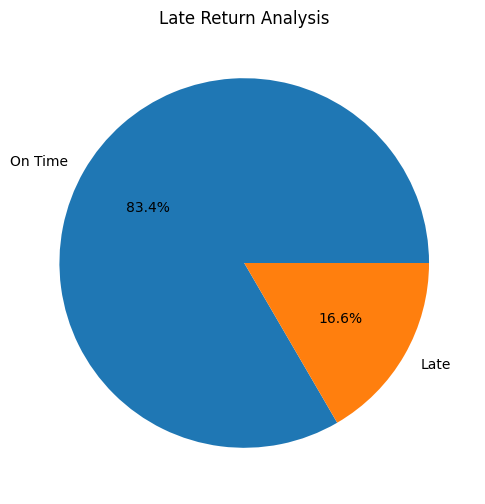

In [15]:
query = """
SELECT 
    is_late_return,
    COUNT(*) AS total
FROM fact_rental
GROUP BY is_late_return
"""

late_df = pd.read_sql(query, engine2)

labels = ['On Time', 'Late']

plt.figure(figsize=(6,6))
plt.pie(
    late_df['total'],
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Late Return Analysis")

plt.show()